Εκπαίδευση σε 1434 ασθενείς (Αλκοολικούς & MASH).

Τρέχει το μοντέλο XGBoost με σταθμισμένο class weight...
Γύρος 1: F1-Score = 0.500
Γύρος 2: F1-Score = 0.592
Γύρος 3: F1-Score = 0.563
Γύρος 4: F1-Score = 0.493
Γύρος 5: F1-Score = 0.474

Τελικό F1-Score (Μέσος Όρος): 0.524

Βέλτιστο κατώφλι απόφασης (Threshold): 0.65 (F1-Score: 0.585)

--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ ---
                         precision    recall  f1-score   support

ALCOHOLIC_LIVER_DISEASE       0.96      0.94      0.95       257
             MASH_NAFLD       0.54      0.63      0.58        30

               accuracy                           0.91       287
              macro avg       0.75      0.79      0.77       287
           weighted avg       0.91      0.91      0.91       287



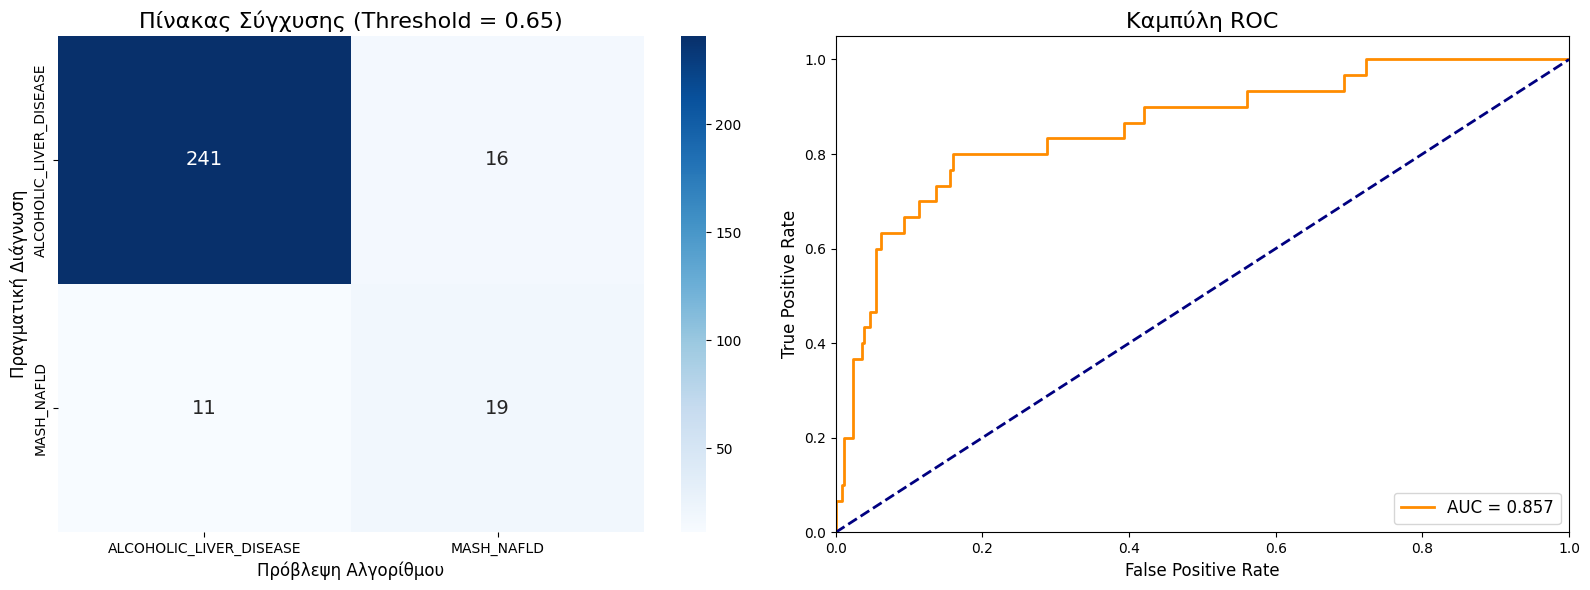

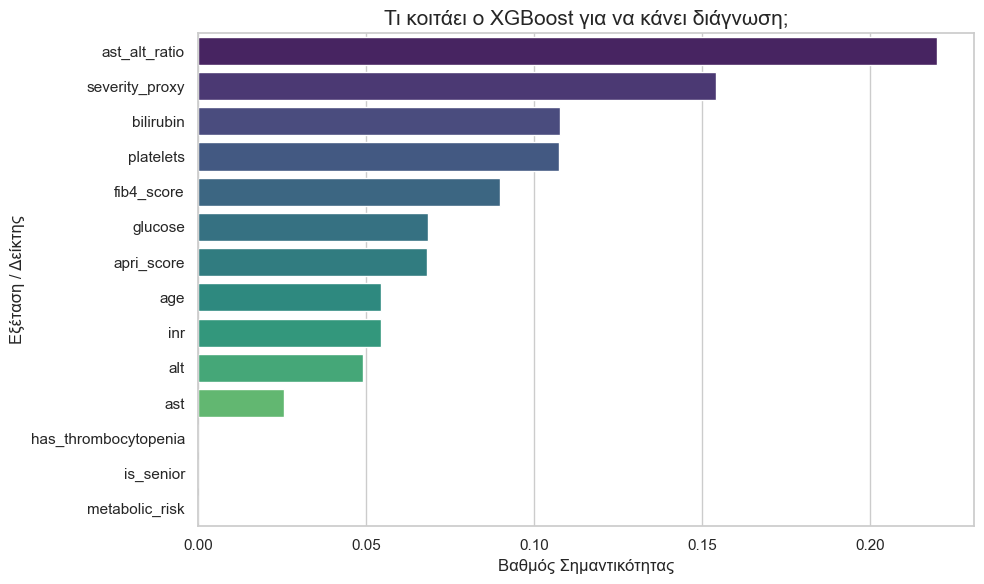

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from xgboost import XGBClassifier

# --- 1. Προετοιμασία Δεδομένων ---

df = pd.read_csv('main.csv')

# Διαχείριση Missing Values στα Labs (με median λόγω skewed κατανομών)
lab_columns = ['alt', 'ast', 'creatinine', 'platelets', 'glucose']
for col in lab_columns:
    df[col] = df[col].fillna(df[col].median())

# Διαχείριση Outliers (Clipping 1% και 99%)
for col in lab_columns:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

df = df.drop_duplicates(subset=['hadm_id'])

# Κρατάμε μόνο τους ασθενείς με ALD ή MASH
df_binary = df[df['liver_group'].isin(['ALCOHOLIC_LIVER_DISEASE', 'MASH_NAFLD'])].copy()

print(f"Εκπαίδευση σε {len(df_binary)} ασθενείς (Αλκοολικούς & MASH).")

# --- 2. Feature Engineering ---

df_binary['has_thrombocytopenia'] = (df_binary['platelets'] < 150).astype(int)
df_binary['is_senior'] = (df_binary['age'] >= 60).astype(int)
df_binary['apri_score'] = (df_binary['ast'] / 40.0) / df_binary['platelets'] * 100
df_binary['metabolic_risk'] = ((df_binary['glucose'] > 100) & (df_binary['age'] > 50)).astype(int)
df_binary['severity_proxy'] = df_binary['bilirubin'] * df_binary['inr']

features = [
    'ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 
    'glucose', 'bilirubin', 'age', 'inr', 
    'has_thrombocytopenia', 'is_senior', 'apri_score', 'metabolic_risk', 'severity_proxy'
]

X = df_binary[features]
y_text = df_binary['liver_group']

# Μετατροπή των κλάσεων σε 0 (ALD) και 1 (MASH)
le = LabelEncoder()
y = le.fit_transform(y_text)


# --- 3. Ρύθμιση του Class Imbalance (Το κλειδί για τα False Positives/Negatives) ---

# Υπολογισμός αναλογίας (Class Imbalance) για το scale_pos_weight
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count  # Λογικά θα είναι κοντά στο 8.5

# Εκπαίδευση XGBoost με Cost-Sensitive προσέγγιση (προσθήκη scale_pos_weight)
xgb_model = XGBClassifier(
    n_estimators=150, 
    max_depth=4, 
    learning_rate=0.05, 
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=spw 
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nΤρέχει το μοντέλο XGBoost με σταθμισμένο class weight...")
# Αξιολογούμε με F1-Score αντί για Accuracy!
scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1') 

for i, score in enumerate(scores):
    print(f"Γύρος {i+1}: F1-Score = {score:.3f}")

print(f"\nΤελικό F1-Score (Μέσος Όρος): {scores.mean():.3f}")


# --- 4. Εκπαίδευση & Βέλτιστο Threshold Tuning ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_model.fit(X_train, y_train)

# Αντί για απόλυτες προβλέψεις, παίρνουμε τις πιθανότητες
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Δοκιμάζουμε πολλά διαφορετικά Thresholds (από 0.1 έως 0.9) για να βρούμε το ιδανικό
thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_thr = 0.5

for thr in thresholds:
    y_pred_temp = (y_probs >= thr).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_thr = thr

print(f"\nΒέλτιστο κατώφλι απόφασης (Threshold): {best_thr:.2f} (F1-Score: {best_f1:.3f})\n")

# Κάνουμε τις Τελικές Προβλέψεις μας χρησιμοποιώντας το ιδανικό Threshold
y_pred_optimal = (y_probs >= best_thr).astype(int)


# --- 5. Αξιολόγηση και Γραφήματα ---

print("--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ ---")
print(classification_report(y_test, y_pred_optimal, target_names=le.classes_))

# Γραφήματα (Confusion Matrix & ROC Curve)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
axes[0].set_title(f'Πίνακας Σύγχυσης (Threshold = {best_thr:.2f})', fontsize=16)
axes[0].set_ylabel('Πραγματική Διάγνωση', fontsize=12)
axes[0].set_xlabel('Πρόβλεψη Αλγορίθμου', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Καμπύλη ROC', fontsize=16)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

# --- 6. Feature Importances (Διόρθωση του NameError) ---

importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')

plt.title('Τι κοιτάει ο XGBoost για να κάνει διάγνωση;', fontsize=15)
plt.xlabel('Βαθμός Σημαντικότητας', fontsize=12)
plt.ylabel('Εξέταση / Δείκτης', fontsize=12)
plt.tight_layout()
plt.show()

Εκπαίδευση σε 1434 ασθενείς (Αλκοολικούς & MASH).

Τρέχει το μοντέλο XGBoost με σταθμισμένο class weight...
Γύρος 1: Accuracy = 0.875
Γύρος 2: Accuracy = 0.899
Γύρος 3: Accuracy = 0.892
Γύρος 4: Accuracy = 0.871
Γύρος 5: Accuracy = 0.860

Τελικό Accuracy (Μέσος Όρος CV): 0.879

Βέλτιστο κατώφλι απόφασης (Threshold): 0.65
Συνολικό Accuracy στο Test Set: 0.906

--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ ---
                         precision    recall  f1-score   support

ALCOHOLIC_LIVER_DISEASE       0.96      0.94      0.95       257
             MASH_NAFLD       0.54      0.63      0.58        30

               accuracy                           0.91       287
              macro avg       0.75      0.79      0.77       287
           weighted avg       0.91      0.91      0.91       287



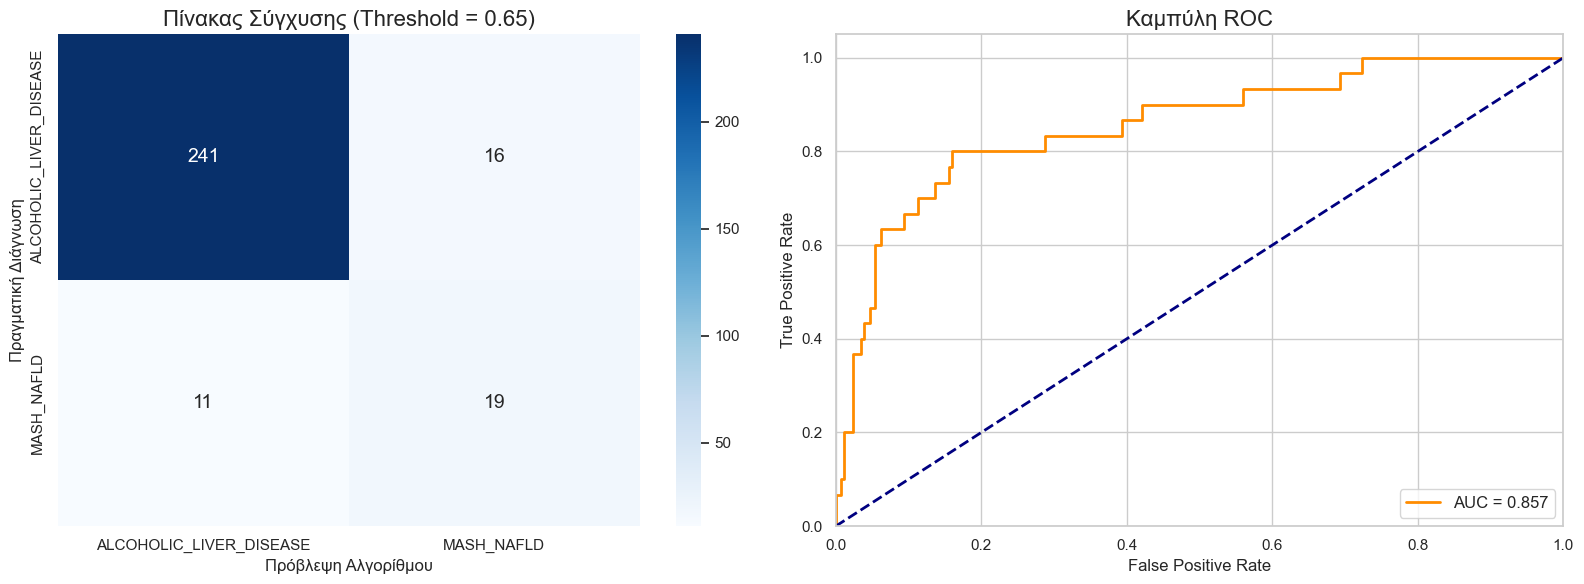

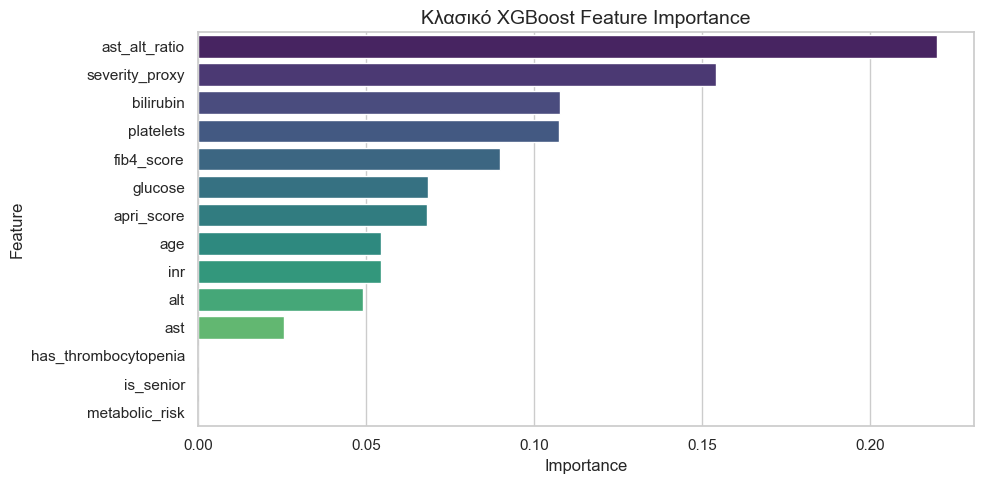


Υπολογισμός SHAP values για πλήρη ερμηνευσιμότητα...


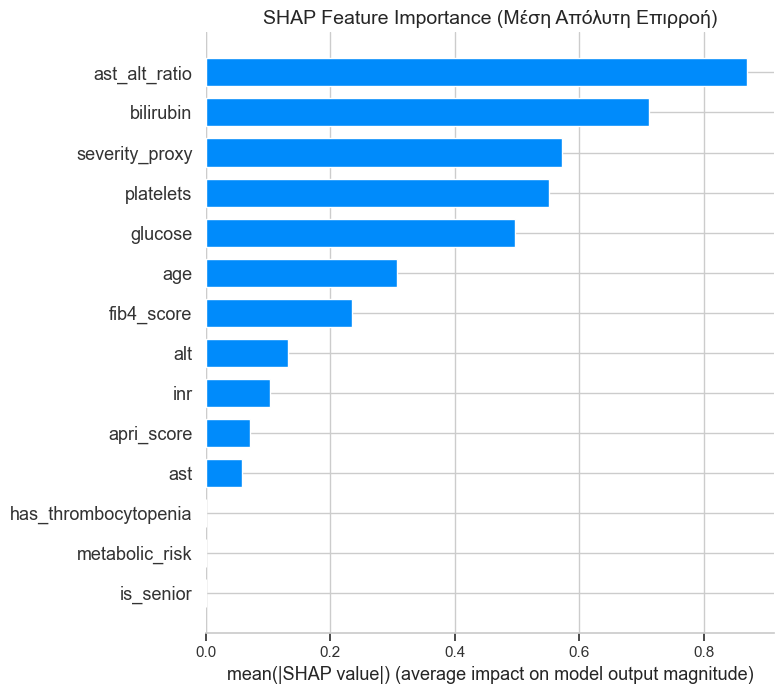

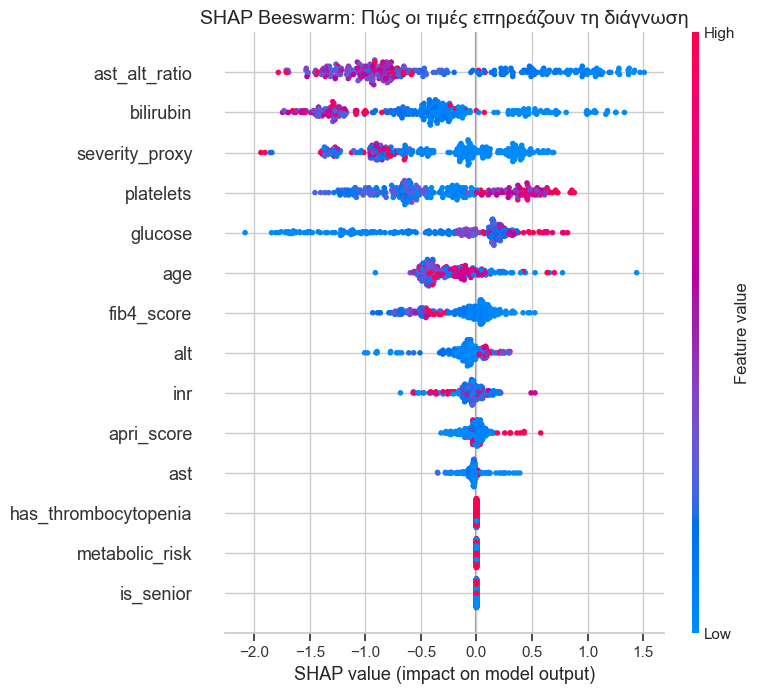


--- Εξήγηση Απόφασης για Μεμονωμένο Ασθενή (Local Explainability) ---


<Figure size 1200x400 with 0 Axes>

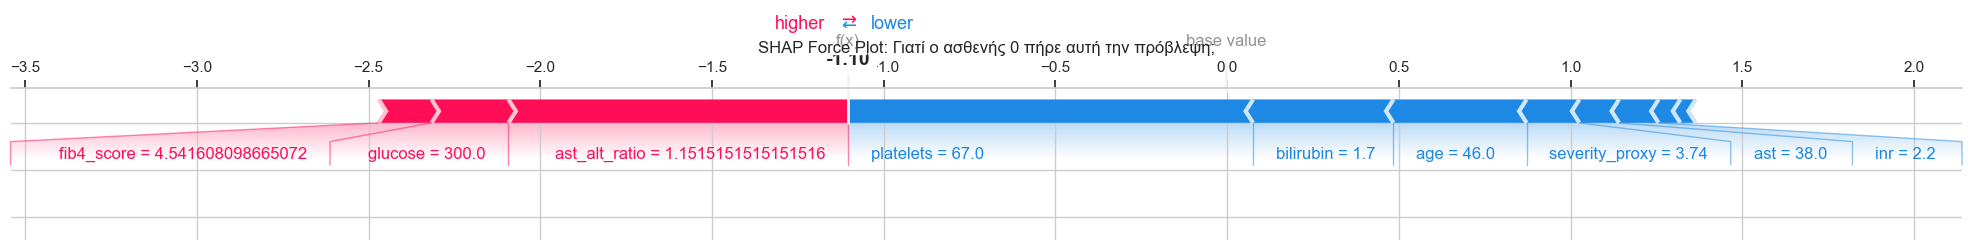

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap  
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, f1_score
from xgboost import XGBClassifier

# ==========================================
# --- 1. Προετοιμασία Δεδομένων ---
# ==========================================
df = pd.read_csv('main.csv')

# Διαχείριση Missing Values στα Labs (με median λόγω skewed κατανομών)
lab_columns = ['alt', 'ast', 'creatinine', 'platelets', 'glucose']
for col in lab_columns:
    df[col] = df[col].fillna(df[col].median())

# Διαχείριση Outliers (Clipping 1% και 99%)
for col in lab_columns:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

df = df.drop_duplicates(subset=['hadm_id'])

# Κρατάμε μόνο τους ασθενείς με ALD ή MASH
df_binary = df[df['liver_group'].isin(['ALCOHOLIC_LIVER_DISEASE', 'MASH_NAFLD'])].copy()

print(f"Εκπαίδευση σε {len(df_binary)} ασθενείς (Αλκοολικούς & MASH).")

# ==========================================
# --- 2. Feature Engineering ---
# ==========================================
df_binary['has_thrombocytopenia'] = (df_binary['platelets'] < 150).astype(int)
df_binary['is_senior'] = (df_binary['age'] >= 60).astype(int)
df_binary['apri_score'] = (df_binary['ast'] / 40.0) / df_binary['platelets'] * 100
df_binary['metabolic_risk'] = ((df_binary['glucose'] > 100) & (df_binary['age'] > 50)).astype(int)
df_binary['severity_proxy'] = df_binary['bilirubin'] * df_binary['inr']

features = [
    'ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 
    'glucose', 'bilirubin', 'age', 'inr', 
    'has_thrombocytopenia', 'is_senior', 'apri_score', 'metabolic_risk', 'severity_proxy'
]

X = df_binary[features]
y_text = df_binary['liver_group']

# Μετατροπή των κλάσεων σε 0 (ALD) και 1 (MASH)
le = LabelEncoder()
y = le.fit_transform(y_text)

# ==========================================
# --- 3. Ρύθμιση του Class Imbalance ---
# ==========================================
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count  

xgb_model = XGBClassifier(
    n_estimators=150, 
    max_depth=4, 
    learning_rate=0.05, 
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=spw 
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nΤρέχει το μοντέλο XGBoost με σταθμισμένο class weight...")
# Εμφανίζουμε το Accuracy στους γύρους εκπαίδευσης
scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy') 

for i, score in enumerate(scores):
    print(f"Γύρος {i+1}: Accuracy = {score:.3f}")

print(f"\nΤελικό Accuracy (Μέσος Όρος CV): {scores.mean():.3f}")

# ==========================================
# --- 4. Εκπαίδευση & Βέλτιστο Threshold Tuning ---
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb_model.fit(X_train, y_train)

y_probs = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_thr = 0.5

# Το "έξυπνο" κόλπο: Ψάχνει το ιδανικό κατώφλι με βάση το F1 για να προστατεύσει τους MASH
for thr in thresholds:
    y_pred_temp = (y_probs >= thr).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp, average='macro')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_thr = thr

# Βρίσκει τις τελικές προβλέψεις και τυπώνει το Accuracy για εσένα
y_pred_optimal = (y_probs >= best_thr).astype(int)
final_acc = accuracy_score(y_test, y_pred_optimal)

print(f"\nΒέλτιστο κατώφλι απόφασης (Threshold): {best_thr:.2f}")
print(f"Συνολικό Accuracy στο Test Set: {final_acc:.3f}\n")


# ==========================================
# --- 5. Αξιολόγηση και Γραφήματα ---
# ==========================================
print("--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ ---")
print(classification_report(y_test, y_pred_optimal, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
axes[0].set_title(f'Πίνακας Σύγχυσης (Threshold = {best_thr:.2f})', fontsize=16)
axes[0].set_ylabel('Πραγματική Διάγνωση', fontsize=12)
axes[0].set_xlabel('Πρόβλεψη Αλγορίθμου', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Καμπύλη ROC', fontsize=16)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# --- 6. Κλασικό Feature Importance (XGBoost) ---
# ==========================================
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Κλασικό XGBoost Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# --- 7. SHAP EXPLAINABILITY ---
# ==========================================
print("\nΥπολογισμός SHAP values για πλήρη ερμηνευσιμότητα...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Μέση Απόλυτη Επιρροή)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm: Πώς οι τιμές επηρεάζουν τη διάγνωση", fontsize=14)
plt.tight_layout()
plt.show()

print("\n--- Εξήγηση Απόφασης για Μεμονωμένο Ασθενή (Local Explainability) ---")
patient_index = 0  
plt.figure(figsize=(12, 4))
shap.force_plot(
    explainer.expected_value, 
    shap_values[patient_index], 
    X_test.iloc[patient_index], 
    feature_names=features, 
    matplotlib=True, 
    show=False
)
plt.title(f'SHAP Force Plot: Γιατί ο ασθενής {patient_index} πήρε αυτή την πρόβλεψη;', fontsize=12)
plt.tight_layout()
plt.show()